# Laboratoire 1 — Simulation d'un qubit et sphère de Bloch

**Objectifs :**
- Comprendre la représentation d'état d'un qubit
- Visualiser la sphère de Bloch
- Simuler l'évolution unitaire avec QuTiP et Qiskit

**Bibliothèques :** QuTiP, Qiskit

In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
%matplotlib inline

---
## 1. Fondement théorique

Un qubit est décrit par un vecteur d'état dans $\mathbb{C}^2$ :

$$ \ket{\psi} = \alpha\ket{0} + \beta\ket{1}, \quad |\alpha|^2 + |\beta|^2 = 1 $$

La **sphère de Bloch** paramétrise tout état pur :

$$ \ket{\psi} = \cos\frac{\theta}{2} \ket{0} + e^{i\phi} \sin\frac{\theta}{2} \ket{1} $$

avec $0 \leq \theta \leq \pi$, $0 \leq \phi < 2\pi$.

---
## 2. États de base avec QuTiP

In [2]:
# États de base
ket0 = qt.basis(2, 0)
ket1 = qt.basis(2, 1)

print("|0⟩ =", ket0)
print("|1⟩ =", ket1)

# Superpositions
ket_plus = (ket0 + ket1).unit()
ket_minus = (ket0 - ket1).unit()
ket_plus_i = (ket0 + 1j * ket1).unit()

print("|+⟩ =", ket_plus)
print("|-⟩ =", ket_minus)
print("|+i⟩ =", ket_plus_i)

|0⟩ = Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [0.]]
|1⟩ = Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [1.]]
|+⟩ = Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.70710678]
 [0.70710678]]
|-⟩ = Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.70710678]
 [-0.70710678]]
|+i⟩ = Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.70710678+0.j        ]
 [0.        +0.70710678j]]


### Question 1
Vérifiez que $|\alpha|^2 + |\beta|^2 = 1$ pour chaque état en calculant $\braket{\psi}{\psi}$.

In [3]:
# Votre code ici
for name, ket in [("|0⟩", ket0), ("|1⟩", ket1), ("|+⟩", ket_plus), ("|-⟩", ket_minus)]:
    norm = (ket.dag() * ket)
    print(f"{name} : ⟨ψ|ψ⟩ = {norm:.2f}")

|0⟩ : ⟨ψ|ψ⟩ = 1.00+0.00j
|1⟩ : ⟨ψ|ψ⟩ = 1.00+0.00j
|+⟩ : ⟨ψ|ψ⟩ = 1.00+0.00j
|-⟩ : ⟨ψ|ψ⟩ = 1.00+0.00j


---
## 3. Opérateurs de Pauli

In [4]:
sx, sy, sz = qt.sigmax(), qt.sigmay(), qt.sigmaz()

print("σ_x =", sx)
print("σ_y =", sy)
print("σ_z =", sz)

# Vérifications
print("X|0⟩ =", sx * ket0)
print("Z|1⟩ =", sz * ket1)
print("X|+⟩ =", sx * ket_plus)
print("Z|+⟩ =", sz * ket_plus)

σ_x = Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0. 1.]
 [1. 0.]]
σ_y = Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0.+0.j 0.-1.j]
 [0.+1.j 0.+0.j]]
σ_z = Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 1.  0.]
 [ 0. -1.]]
X|0⟩ = Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [1.]]
Z|1⟩ = Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.]
 [-1.]]
X|+⟩ = Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.70710678]
 [0.70710678]]
Z|+⟩ = Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.70710678]
 [-0.70710678]]


### Question 2
Montrez que $|+\rangle$ est un état propre de $X$ et que $|0\rangle$ est un état propre de $Z$.
Identifiez les valeurs propres.

In [5]:
# Votre code ici
# Utilisez .eigenstates() pour trouver les valeurs propres
eigvals_X, eigvecs_X = sx.eigenstates()
print("Valeurs propres de X :", eigvals_X)
print("Vecteurs propres de X :")
for i, v in enumerate(eigvecs_X):
    print(f"  λ={eigvals_X[i]} : {v}")

Valeurs propres de X : [-1.  1.]
Vecteurs propres de X :
  λ=-1.0 : Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[-0.70710678]
 [ 0.70710678]]
  λ=1.0 : Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.70710678]
 [0.70710678]]


---
## 4. Visualisation — Sphère de Bloch

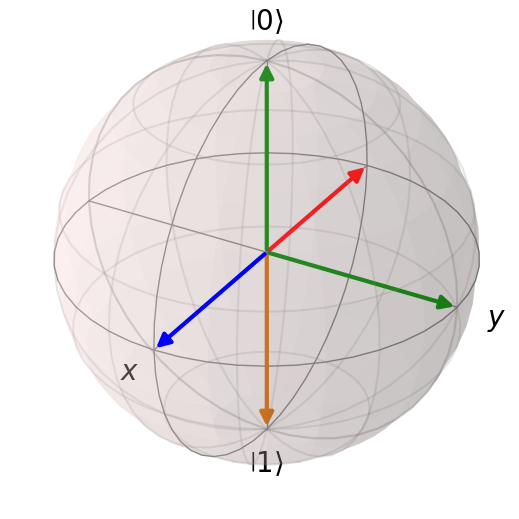

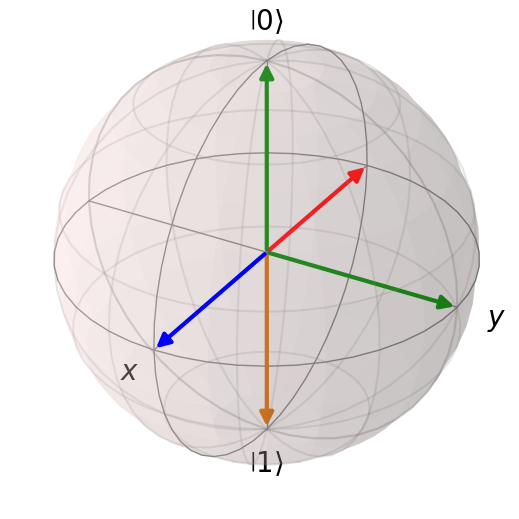

In [6]:
bloch = qt.Bloch()
bloch.add_states([ket0, ket1, ket_plus, ket_minus, ket_plus_i])
bloch.show()

### Question 3
Ajoutez l'état $\ket{-i} = (\ket{0} - i\ket{1})/\sqrt{2}$ à la sphère de Bloch.
Où se trouve-t-il par rapport à $\ket{+i}$ ?

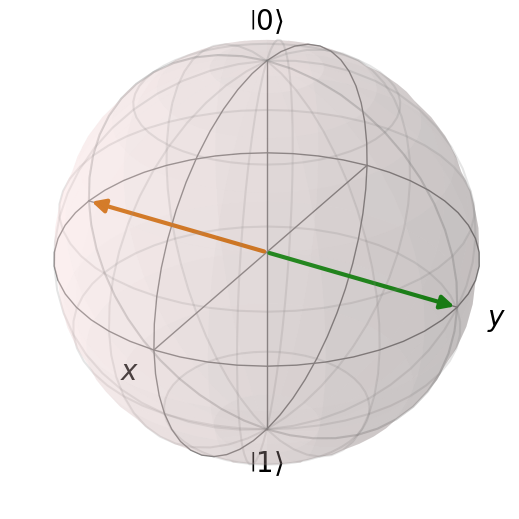

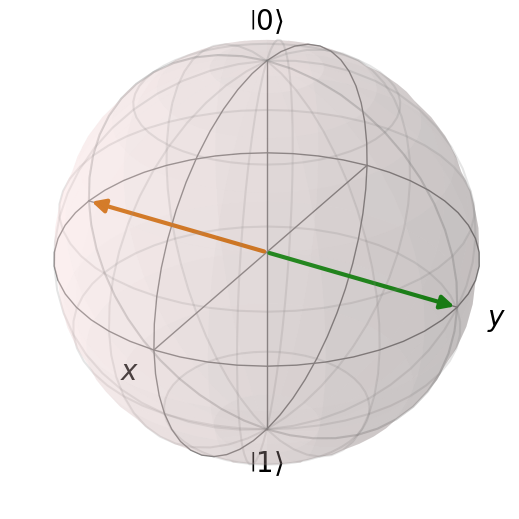

In [7]:
# Votre code ici
ket_minus_i = (ket0 - 1j * ket1).unit()
bloch2 = qt.Bloch()
bloch2.add_states([ket_plus_i, ket_minus_i])
bloch2.show()

---
## 5. Évolution unitaire

### 5.1 Rotation autour de l'axe z

Sous $H = \frac{\hbar\omega}{2}\sigma_z$, l'évolution est :

$$ U(t) = e^{-i\omega t \sigma_z / 2} $$

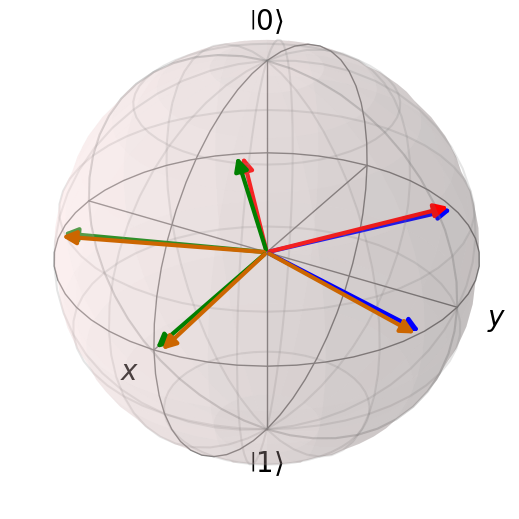

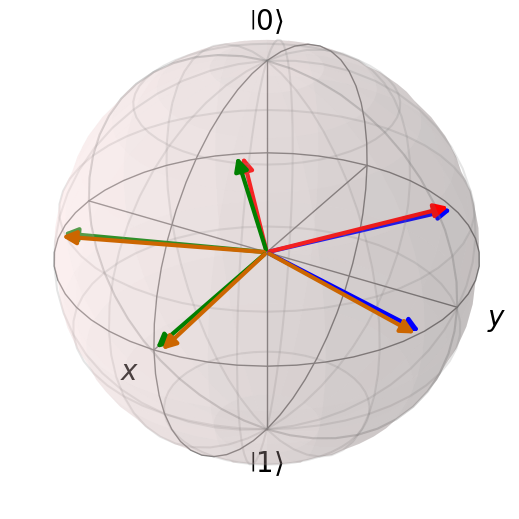

In [8]:
omega = 1.0
H = omega / 2 * qt.sigmaz()
psi0 = ket_plus  # |+⟩

tlist = np.linspace(0, 4*np.pi, 200)
result = qt.sesolve(H, psi0, tlist)

# Visualisation de la trajectoire
bloch = qt.Bloch()
bloch.add_states(result.states[::20])
bloch.show()

### Question 4
Modifiez l'état initial à $\ket{0}$ et observez la trajectoire. Pourquoi ne bouge-t-il pas ?

Essayez maintenant avec $H = \frac{\omega}{2}(\sigma_x + \sigma_z)$.

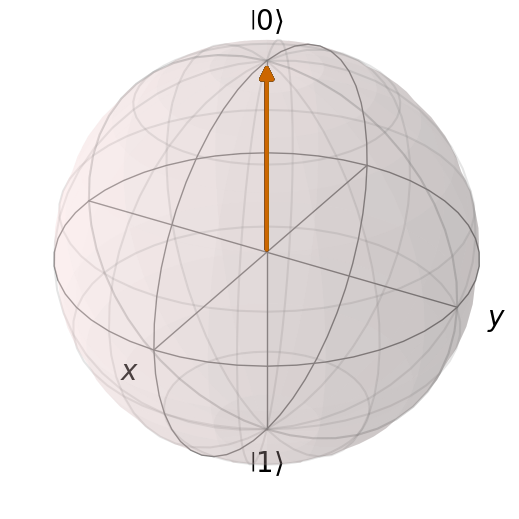

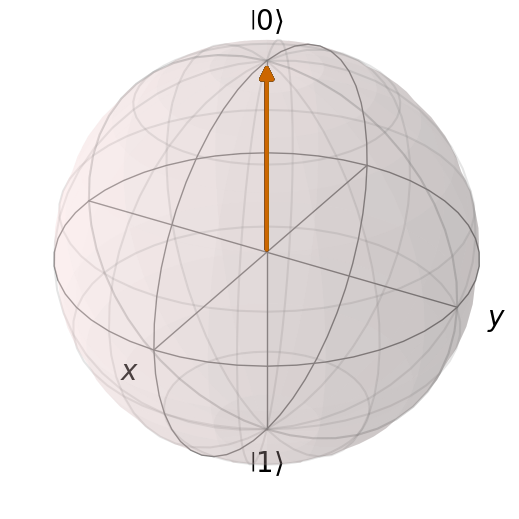

In [9]:
# Question 4a : |0⟩ sous H = ω σ_z / 2
psi0_0 = qt.basis(2, 0)
result_0 = qt.sesolve(H, psi0_0, tlist)
bloch_0 = qt.Bloch()
bloch_0.add_states(result_0.states[::20])
bloch_0.show()

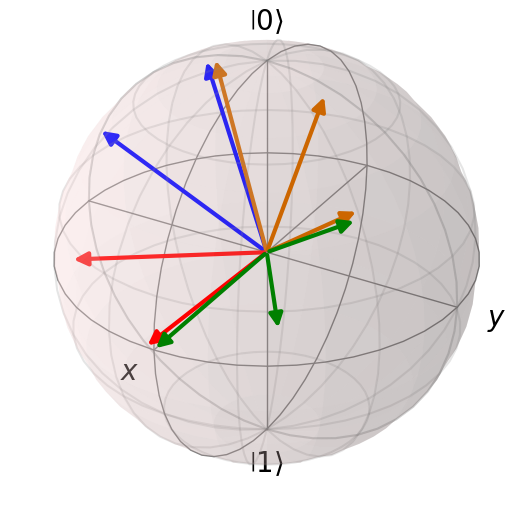

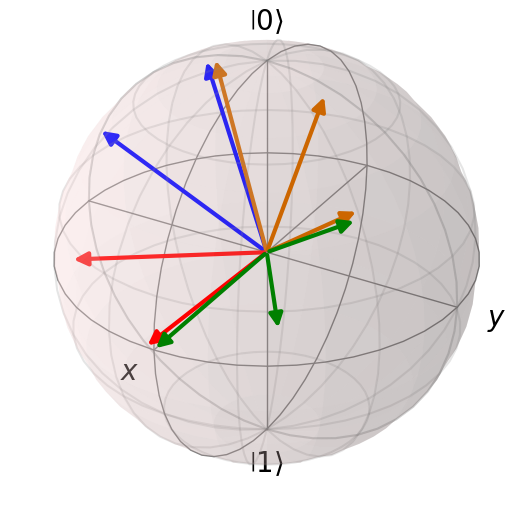

In [10]:
# Question 4b : Hamiltonien avec rotation autour d'un axe incliné
H2 = omega / 2 * (qt.sigmax() + qt.sigmaz())
result2 = qt.sesolve(H2, ket_plus, tlist)
bloch_2 = qt.Bloch()
bloch_2.add_states(result2.states[::20])
bloch_2.show()

---
## 6. Circuit Qiskit

In [11]:
# Création d'états avec Qiskit
qc = QuantumCircuit(1)
qc.h(0)  # |+⟩

state = Statevector.from_instruction(qc)
print("État :", state)
print("Amplitudes :", state.data)
print("Probabilité |0⟩ :", abs(state.data[0])**2)
print("Probabilité |1⟩ :", abs(state.data[1])**2)

État : Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))
Amplitudes : [0.70710678+0.j 0.70710678+0.j]
Probabilité |0⟩ : 0.4999999999999999
Probabilité |1⟩ : 0.4999999999999999


In [12]:
# Circuit : |0⟩ → |1⟩ via X
qc_x = QuantumCircuit(1)
qc_x.x(0)
state_x = Statevector.from_instruction(qc_x)
print("X|0⟩ =", state_x)

# Superposition avec phase
qc_phase = QuantumCircuit(1)
qc_phase.h(0)
qc_phase.t(0)  # Phase π/4
state_phase = Statevector.from_instruction(qc_phase)
print("T H |0⟩ =", state_phase)

X|0⟩ = Statevector([0.+0.j, 1.+0.j],
            dims=(2,))
T H |0⟩ = Statevector([0.70710678+0.j , 0.5       +0.5j],
            dims=(2,))


### Question 5
Construisez un circuit Qiskit qui génère l'état $\frac{\ket{0} + e^{i\pi/3}\ket{1}}{\sqrt{2}}$.
Utilisez les portes `h` et `p(theta)` (phase gate).

In [13]:
# Votre code ici
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

qc_custom = QuantumCircuit(1)
# Complétez : H puis phase
qc_custom.h(0)
qc_custom.p(np.pi/3, 0)  # Phase de π/3

state_custom = Statevector.from_instruction(qc_custom)
print("État personnalisé :", state_custom)

# Vérification
alpha, beta = state_custom.data
print(f"α = {alpha:.4f}, β = {beta:.4f}")
print(f"|α|² + |β|² = {abs(alpha)**2 + abs(beta)**2:.4f}")

État personnalisé : Statevector([0.70710678+0.j        , 0.35355339+0.61237244j],
            dims=(2,))
α = 0.7071+0.0000j, β = 0.3536+0.6124j
|α|² + |β|² = 1.0000


---
## 7. Exercices supplémentaires

1. Générez un état avec $\theta = \pi/4, \phi = \pi/3$ et vérifiez sa position sur la sphère de Bloch.
2. Appliquez une rotation $R_x(\pi/2)$ à $\ket{0}$ et décrivez le résultat.
3. Calculez la probabilité de mesurer $\ket{0}$ pour un état qui a subi une rotation $R_y(\theta)$ à partir de $\ket{0}$.
4. Comparez les portes Qiskit avec les matrices QuTiP pour $H$, $S$, $T$ et vérifiez qu'elles sont unitaires.

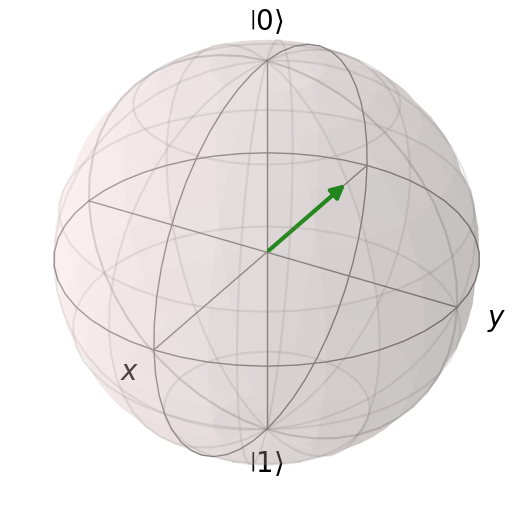

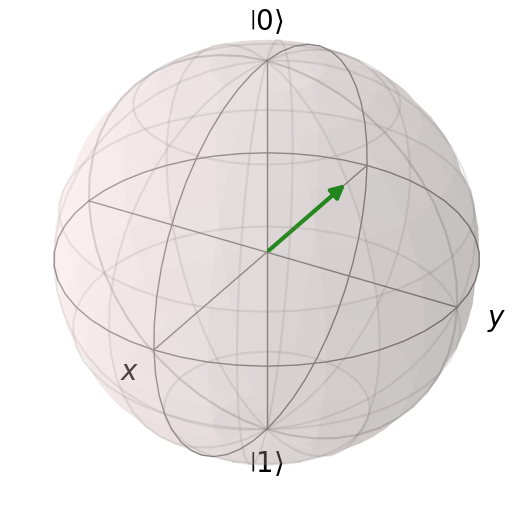

In [14]:
# Exercice 1 : état avec θ=π/4, ϕ=π/3
theta, phi = np.pi/4, np.pi/3
psi = np.cos(theta/2) * ket0 + np.exp(1j*phi) * np.sin(theta/2) * ket1

bloch = qt.Bloch()
bloch.add_states([psi])
bloch.show()

In [15]:
# Exercice 2 : rotation Rx(π/2)
theta = np.pi/2
Rx = (-1j * theta * qt.sigmax() / 2).expm()
psi_rx = Rx * ket0
print("Rx(π/2)|0⟩ =", psi_rx)

Rx(π/2)|0⟩ = Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.70710678+0.j        ]
 [0.        -0.70710678j]]


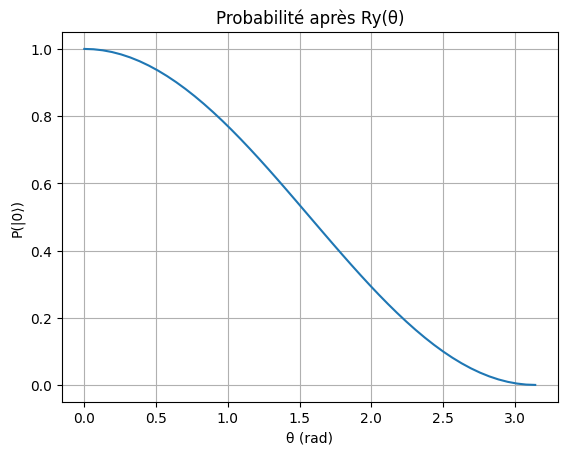

In [16]:
# Exercice 3 : probabilité |0⟩ après Ry(θ)
thetas = np.linspace(0, np.pi, 50)
probs = []
for th in thetas:
    Ry = (-1j * th * qt.sigmay() / 2).expm()
    psi_ry = Ry * ket0
    prob = abs(ket0.dag() * psi_ry)**2
    probs.append(prob)

plt.plot(thetas, probs)
plt.xlabel('θ (rad)')
plt.ylabel('P(|0⟩)')
plt.title('Probabilité après Ry(θ)')
plt.grid()
plt.show()

---
## 8. Vérification des portes (Exercice 4)

In [17]:
# Vérification : H est unitaire
H = (1/np.sqrt(2)) * qt.Qobj([[1, 1], [1, -1]])
print("H†H =", H.dag() * H)
print("HH† =", H * H.dag())
print("H unitaire ?", (H.dag() * H - qt.qeye(2)).norm() < 1e-10)

H†H = Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[1. 0.]
 [0. 1.]]
HH† = Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[1. 0.]
 [0. 1.]]
H unitaire ? True
